In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [31]:
file_path = 'Country-data.csv'

In [32]:
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohan0301/unsupervised-learning-on-country-data",
  file_path,
)
print("First 5 records:", df.head())

/tmp/ipykernel_12591/1244349508.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:                country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


               country  child_mort   exports    health   imports    income  \
0          Afghanistan    0.426485  0.049482  0.358608  0.257765  0.008047   
1              Albania    0.068160  0.139531  0.294593  0.279037  0.074933   
2              Algeria    0.120253  0.191559  0.146675  0.180149  0.098809   
3               Angola    0.566699  0.311125  0.064636  0.246266  0.042535   
4  Antigua and Barbuda    0.037488  0.227079  0.262275  0.338255  0.148652   

   inflation  life_expec  total_fer      gdpp  
0   0.126144    0.475345   0.736593  0.003073  
1   0.080399    0.871795   0.078864  0.036833  
2   0.187691    0.875740   0.274448  0.040365  
3   0.245911    0.552268   0.790221  0.031488  
4   0.052213    0.881657   0.154574  0.114242  


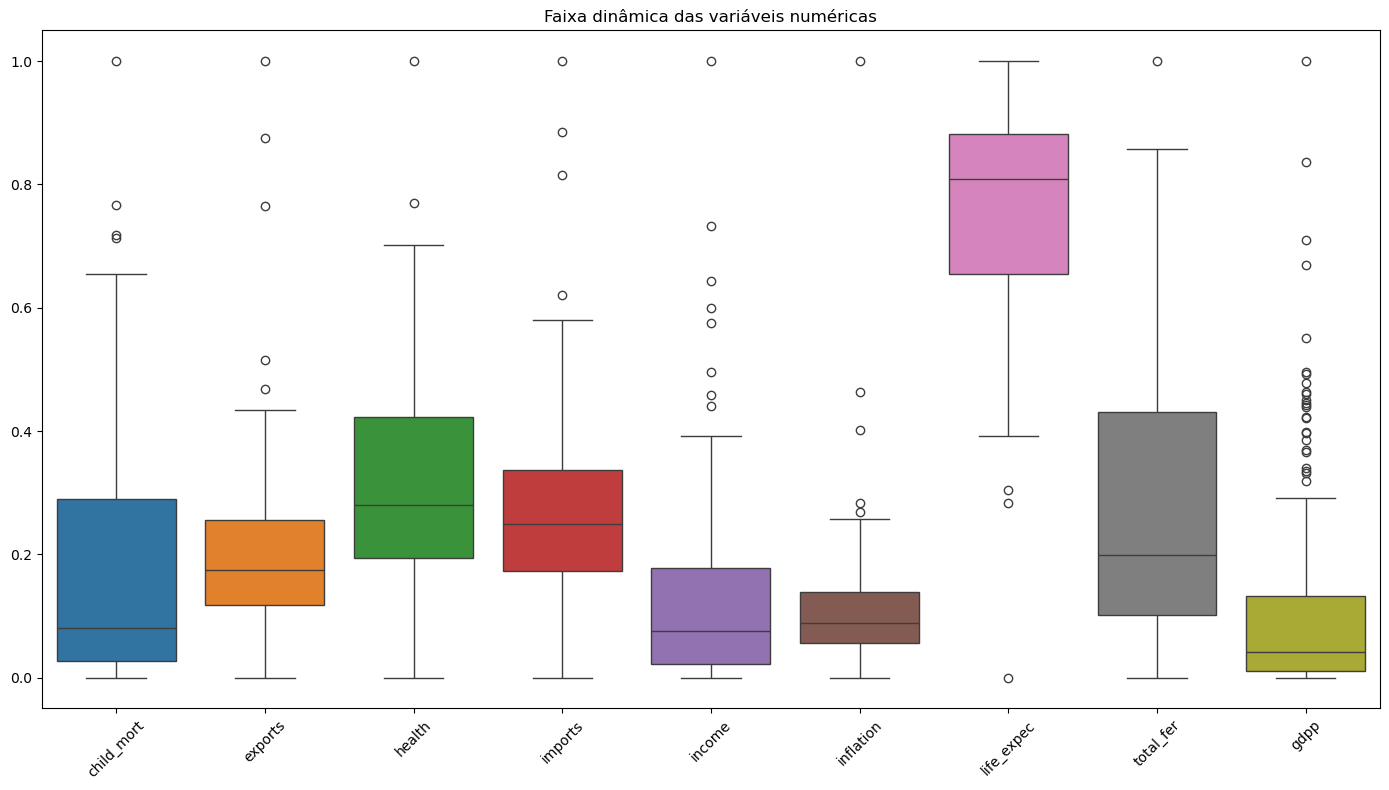

In [34]:
numeric_cols = df.columns.drop('country')

from sklearn.preprocessing import MinMaxScaler
# Instanciar o normalizador
scaler = MinMaxScaler()

# Aplicar a normalização
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Verificar o resultado
print(df_scaled.head())

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_scaled[numeric_cols])
plt.xticks(rotation=45)
plt.title('Faixa dinâmica das variáveis numéricas')
plt.tight_layout()
plt.show()

In [35]:
from sklearn.preprocessing import StandardScaler

X = df_scaled.drop('country', axis=1)
X_scaled_df = pd.DataFrame(df_scaled, columns=X.columns)
print(X_scaled_df.head())

   child_mort   exports    health   imports    income  inflation  life_expec  \
0    0.426485  0.049482  0.358608  0.257765  0.008047   0.126144    0.475345   
1    0.068160  0.139531  0.294593  0.279037  0.074933   0.080399    0.871795   
2    0.120253  0.191559  0.146675  0.180149  0.098809   0.187691    0.875740   
3    0.566699  0.311125  0.064636  0.246266  0.042535   0.245911    0.552268   
4    0.037488  0.227079  0.262275  0.338255  0.148652   0.052213    0.881657   

   total_fer      gdpp  
0   0.736593  0.003073  
1   0.078864  0.036833  
2   0.274448  0.040365  
3   0.790221  0.031488  
4   0.154574  0.114242  


In [36]:
from sklearn.cluster import KMeans
country_data = KMeans(n_clusters=3, random_state=42).fit(X_scaled_df.iloc[:, 0:])
centroids = country_data.cluster_centers_
country_data

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


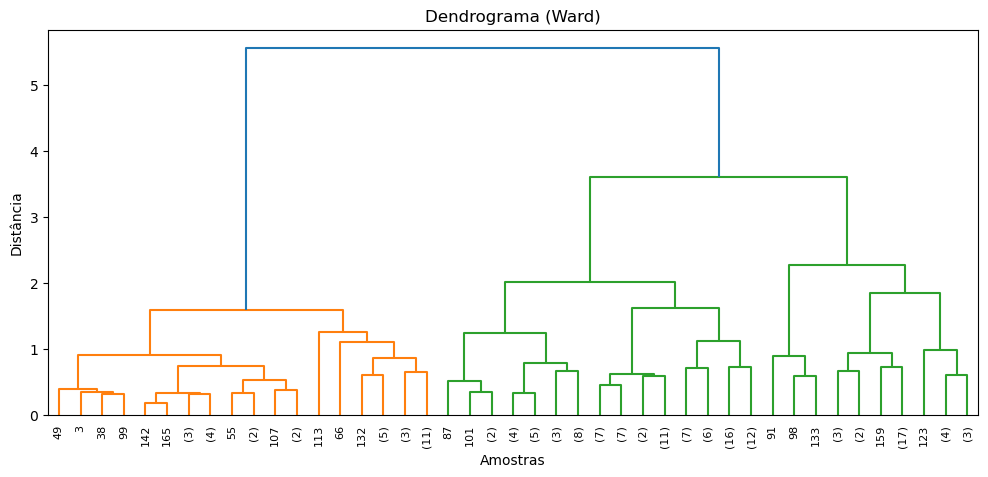

In [37]:
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt

X = X_scaled_df.values

Z = hierarchy.linkage(X, method='ward')

plt.figure(figsize=(12, 5))
dn = hierarchy.dendrogram(Z, truncate_mode='level', p=5)
plt.title('Dendrograma (Ward)')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.show()

In [38]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 3
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_hier = agg.fit_predict(X)

In [39]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

# rótulos KMeans
labels_kmeans = country_data.labels_

sil_hier = silhouette_score(X, labels_hier)
sil_km = silhouette_score(X, labels_kmeans)
ari = adjusted_rand_score(labels_kmeans, labels_hier)

print(f"Silhouette Agglomerative: {sil_hier:.4f}")
print(f"Silhouette KMeans:         {sil_km:.4f}")
print(f"Adjusted Rand Index (KMeans vs Hier): {ari:.4f}")

Silhouette Agglomerative: 0.3163
Silhouette KMeans:         0.3398
Adjusted Rand Index (KMeans vs Hier): 0.6981


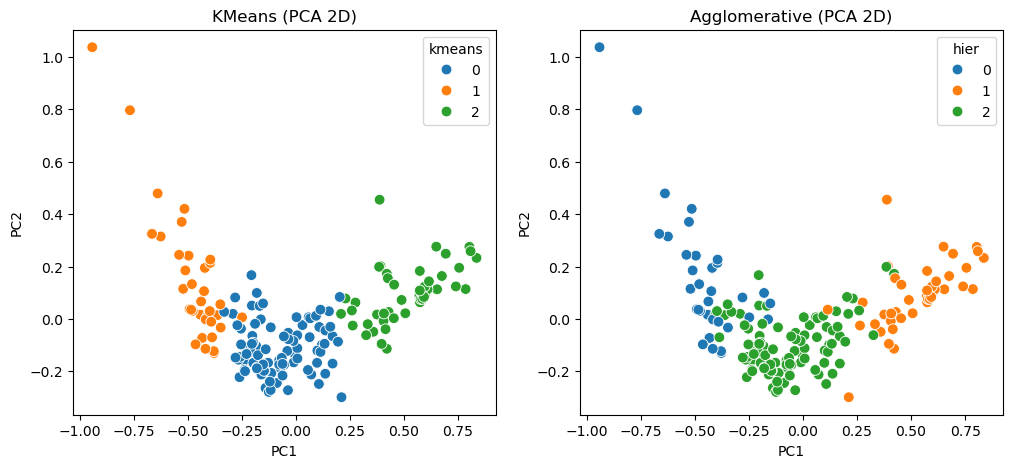

In [49]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

pca = PCA(n_components=2)
proj = pca.fit_transform(X)
df_viz = pd.DataFrame(proj, columns=['PC1','PC2'])
df_viz['kmeans'] = labels_kmeans
df_viz['hier'] = labels_hier
df_viz['country'] = X_scaled_df.index

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(data=df_viz, x='PC1', y='PC2', hue='kmeans', palette='tab10', s=60)
plt.title('KMeans (PCA 2D)')
plt.subplot(1,2,2)
sns.scatterplot(data=df_viz, x='PC1', y='PC2', hue='hier', palette='tab10', s=60)
plt.title('Agglomerative (PCA 2D)')
plt.show()

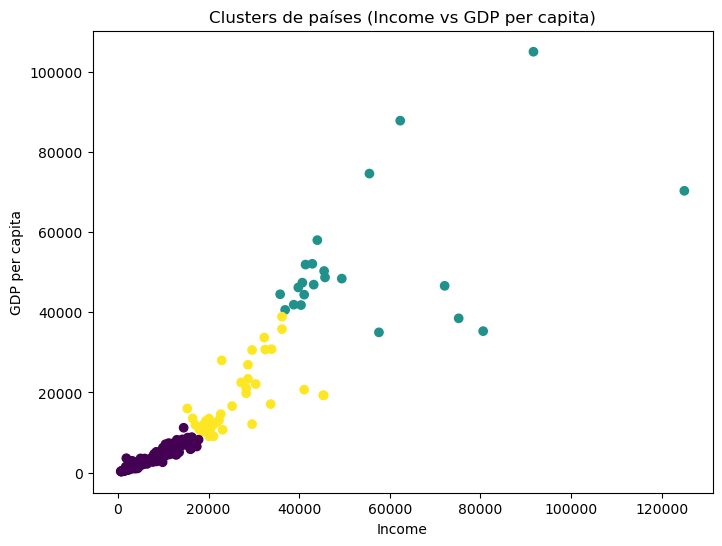

In [63]:
X = df[['income', 'gdpp']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(df['income'], df['gdpp'], c=df['cluster'], cmap='viridis')
plt.xlabel("Income")
plt.ylabel("GDP per capita")
plt.title("Clusters de países (Income vs GDP per capita)")
plt.show()

In [67]:
# Centroids na escala normalizada
print(kmeans.cluster_centers_)

# Se quiser voltar para os valores originais (income e gdpp):
medoide = scaler.inverse_transform(kmeans.cluster_centers_)
print("Centroids (income, gdpp):")
print(medoide)


[[-0.55456005 -0.5411679 ]
 [ 1.9591466   2.16651745]
 [ 0.48182833  0.31455327]]
Centroids (income, gdpp):
[[ 6485.89908257  3074.99082569]
 [54800.         52554.54545455]
 [26405.55555556 18712.22222222]]


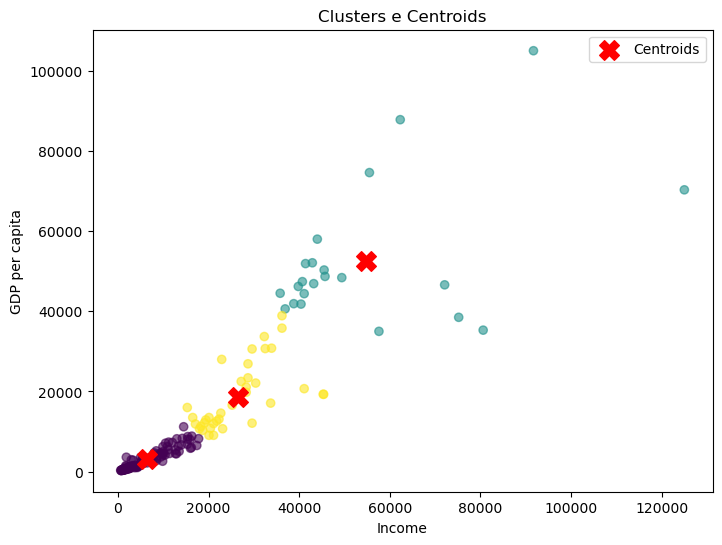

In [68]:
plt.figure(figsize=(8,6))
plt.scatter(df['income'], df['gdpp'], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.scatter(medoide[:,0], medoide[:,1], c='red', s=200, marker='X', label='Centroids')
plt.xlabel("Income")
plt.ylabel("GDP per capita")
plt.title("Clusters e Centroids")
plt.legend()
plt.show()